In [1]:
import sys
sys.path.insert(0,'../src/')

import sbdynt as sbd

# Stability Indicators

Stability indicators can be produced in much the same way as the proper elements. 3 of the stability indicators provided by SBDynT can be computed directly from the default small_body integrations for proper elements, namely:
    (1) ACFI
    (2) Entropy
    (3) Power Distribution

The Clones Root Mean Square indicator can also be produced from the integration if clones were included in the above integration. 

In addition, if proper elements have already been computed, the Distance Metric stability indicator can be generated directly from the values contained within the small_body object. 



Stability indicators can be computed generally using the ``compute_stability`` function, which will compute stability indciators for every indicator which can be computed from the given simulation. For example, let us look at the process of computing stability indicators with the ``Lempo`` and ``Helga`` small_body objects below.


**NOTE OF CAUTION:** we know we have chosen example objects that don't experience very close encounters with planets, so we are setting ``integrator='whfast'`` to speed up the integration so the TNO and Asteroid examples only takes ~5 minutes each to fully execute. **The safest thing to do is to not pass ``integrator`` to ``run_tno`` or ``run_ast``** as that will result in the use of the mercurius hybrid integrator, which can correctly handle a TNO's close encounters with Neptune. Use ``integrator='whfast'`` with caution!




In [2]:
flag, tno_result, sim1 = sbd.run_tno(des='Lempo', clones=3, datadir='outputs-from-example-notebooks', 
                                     deletefile=True, run_ML=True, run_proper=True, 
                                     run_stability=True, logfile='screen', integrator='whfast')

Initializing a TNO simulation instance by querying JPL
SBDB query results saved to outputs-from-example-notebooks/Lempo-Mar-18-2026.pkl

simulation epoch: 2458406.5

Rebound simulation initial conditions saved to outputs-from-example-notebooks/Lempo-ic.bin

Running TNO ML

Running the 0.5 Myr short classification integration

Running Lempo from 0.0 to 500000.0 years 
using mercurius outputting every 50.0 years 
to simulation archivefile outputs-from-example-notebooks/Lempo-simarchive.bin
starting at 2026-03-18 19:19:01.420922

finishing at 2026-03-18 19:21:27.739851

Running the classification integration to 10 Myr

Running Lempo from 500000.0 to 10000000.0 years 
using mercurius outputting every 1000.0 years 
to simulation archivefile outputs-from-example-notebooks/Lempo-simarchive.bin
starting at 2026-03-18 19:21:35.691678

finishing at 2026-03-18 19:25:49.924299

running the machine learning classifier on the simulation data features

#Most common classification: Nresonant
#Shared b

In [3]:
flag, ast_result, sim2 = sbd.run_ast(des='Helga', clones=3, datadir='outputs-from-example-notebooks',
                                     deletefile=True, run_stability=True,
                                     run_proper=True,logfile='screen',
                                     integrator='whfast')

Initializing an Asteroid simulation instance by querying JPL for designation: Helga
SBDB query results saved to outputs-from-example-notebooks/Helga-Mar-18-2026.pkl

simulation epoch: 2457875.5

Rebound simulation initial conditions saved to outputs-from-example-notebooks/Helga-ic.bin

Running Asteroid integration for the synthetic
proper elements calculation

Running Helga from 0.0 to 5000000.0 years 
using whfast outputting every 500.0 years 
to simulation archivefile outputs-from-example-notebooks/Helga-simarchive.bin
starting at 2026-03-18 19:42:45.013444

finishing at 2026-03-18 19:49:34.886393

Loaded integration for Helga from outputs-from-example-notebooks/Helga-ic.bin
simulation is at time 0.0 years
integrator is ias15

Found Helga and 3 clones in the simulation

Running Helga from 0.0 to -5000000.0 years 
using whfast outputting every 500.0 years 
to simulation archivefile outputs-from-example-notebooks/Helga-simarchive.bin
starting at 2026-03-18 19:49:34.896512

finishing at


You may also run the full analysis using the ``run_existing_tno/ast`` functions, which perform the chaos indicator analysis using the simulation archive described by the inputs. 

In [2]:
flag, tno_result = sbd.analyze_tno_run(des='Lempo', clones=3, datadir='outputs-from-example-notebooks', 
                                       archivefile=None, logfile=False, run_ML=False, 
                                       run_proper=False, run_stability=True, output_arrays=False)

flag, ast_result = sbd.analyze_ast_run(des='Helga', clones=3, datadir='outputs-from-example-notebooks',
                                       archivefile=None, logfile=False, run_proper=False, 
                                       run_stability=True, output_arrays=False)

In [3]:
tno_result.stability_indicators.print_results()
print("\n\n")
ast_result.stability_indicators.print_results()

Small Body:Lempo, Stability Indicator Results
ACFI: ( False ),  0.964  >  0.75
Entropy: ( False ),  0.9584872359893596  >  0.95
Power: ( True ),  0.589315558153363  <  0.9
Distance Metric: Undefined
Clone_RMS_a: ( False ),  0.0023210087908904393  <  0.01
Clone_RMS_e: ( False ),  0.008870110918249803  <  0.01
Clone_RMS_sinI: ( True ),  0.02535400429368785  >  0.01



Small Body:Helga, Stability Indicator Results
ACFI: ( True ),  0.464  <  0.75
Entropy: ( True ),  0.9445799310366458  <  0.95
Power: ( True ),  0.6598039869026902  <  0.9
Distance Metric: Undefined
Clone_RMS_a: ( False ),  0.004759032459727579  <  0.01
Clone_RMS_e: ( False ),  0.025359814664147478  >  0.01
Clone_RMS_sinI: ( True ),  0.018064891361666644  >  0.01


Now that we have run an integration, there is enough data present to compute the ACFI, Entropy, and Power chaos indicators.

However, since we set the run_proper flag to False, proper elements have not yet been computed, and so the Distance Metric indicator remains empty in both cases.

Let us run the analysis again and include the proper_elements computation to get Distance Metric results. 

We will also set ``otuput_arrays=True`` to facilitate the plotting commands below

In [4]:
flag, tno_result = sbd.analyze_tno_run(des='Lempo', clones=3, datadir='outputs-from-example-notebooks',
                                       archivefile=None, logfile=False, run_ML=False, 
                                       run_proper=True, run_stability=True, output_arrays=True)

flag, ast_result = sbd.analyze_ast_run(des='Helga', clones=3, datadir='outputs-from-example-notebooks',
                                       archivefile=None, logfile=False, run_proper=True, 
                                       run_stability=True, output_arrays=True)

print()
tno_result.stability_indicators.print_results()


print()
ast_result.stability_indicators.print_results()


Small Body:Lempo, Stability Indicator Results
ACFI: ( False ),  0.964  >  0.75
Entropy: ( False ),  0.9584872359893596  >  0.95
Power: ( True ),  0.589315558153363  <  0.9
Distance Metric: Undefined
Clone_RMS_a: ( False ),  0.0023210087908904393  <  0.01
Clone_RMS_e: ( False ),  0.008870110918249803  <  0.01
Clone_RMS_sinI: ( True ),  0.02535400429368785  >  0.01

Small Body:Helga, Stability Indicator Results
ACFI: ( True ),  0.464  <  0.75
Entropy: ( True ),  0.9445799310366458  <  0.95
Power: ( True ),  0.6598039869026902  <  0.9
Distance Metric: Undefined
Clone_RMS_a: ( False ),  0.004759032459727579  <  0.01
Clone_RMS_e: ( False ),  0.025359814664147478  >  0.01
Clone_RMS_sinI: ( True ),  0.018064891361666644  >  0.01


In [7]:
tno_result.proper_elements.print_results()

Lempo  Proper Element Results from a  150  Myr integration with outputs every 5000 years
Best-fit orbit
                         a (au)      ecc        inc (deg)   g("/yr)      s("/yr)   
Osculating Elements     39.406428    0.224541    8.415039   N/A          N/A       
Mean Elements           39.403442    0.231560    5.686700    -0.449141    -0.352474
Proper Elements         39.403442    0.203153    5.521508    -0.433655    -0.392331
Proper Errors            2.15e-05    3.99e-02    1.67e-01     5.53e-02     2.27e-02

Clone Proper Elements
Clone   0               39.403470    0.151353    5.690491    -0.495499    -0.370968
Clone   1               39.403410    0.160778    4.870567    -0.499276    -0.366981
Clone   2               39.403421    0.192528    5.059527    -0.428596    -0.390247

RMS(Clones+Best-fit)     2.29e-05    2.15e-02    5.78e-03     3.32e-02     1.13e-02

Lempo may have been scattered during the simulation at t=-68550000.03323929 years, near snapshot #1290


We can see that the scattered flag and planet-crossing flag were both tripped for the TNO Lempo. Let's make plots showing the time evolution of Lempo's orbital elements to see this in the orbit of the object.

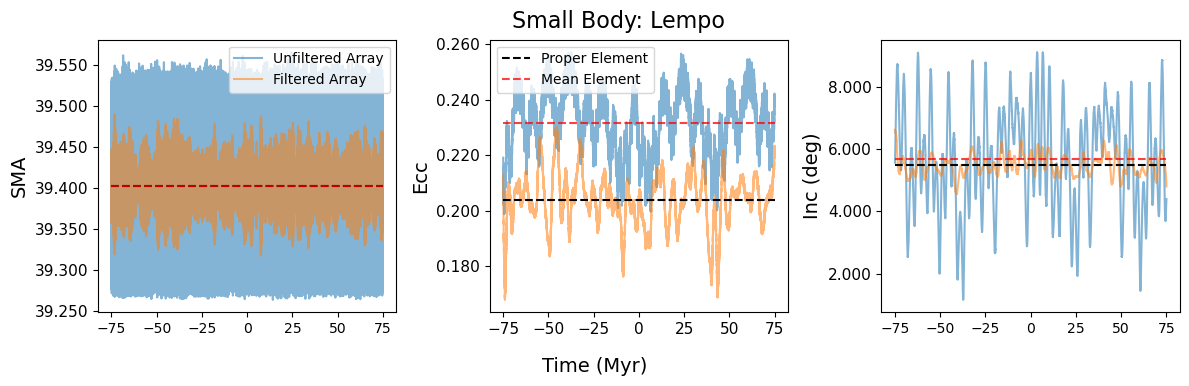

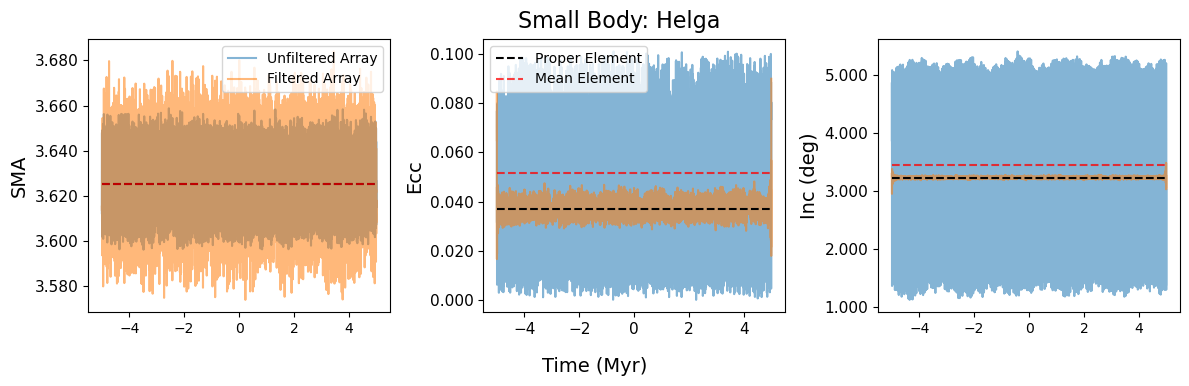

In [8]:
tno_result.proper_elements.plot_time_arrays()
ast_result.proper_elements.plot_time_arrays()

We can see evidence in all 3 orbital elements of chaotic motion in Lempo's orbit. While the semi-major axis evolution seems reasonable at first glance, the amplitude of the change in semi-major axis is larger than it would be for a stable object. In addition, we can see scattering effects in the osculating eccentricity and inclination evolution, as angular momentum exchange coincides with the chaotic energy exchange.

In addition, we can confirm that, as a Plutino with e>0.2, Lempo does experience a planet crossing orbit, with q<34. Indeed, the orbit intersects/crosses Neptune's orbit at peak values of e. 

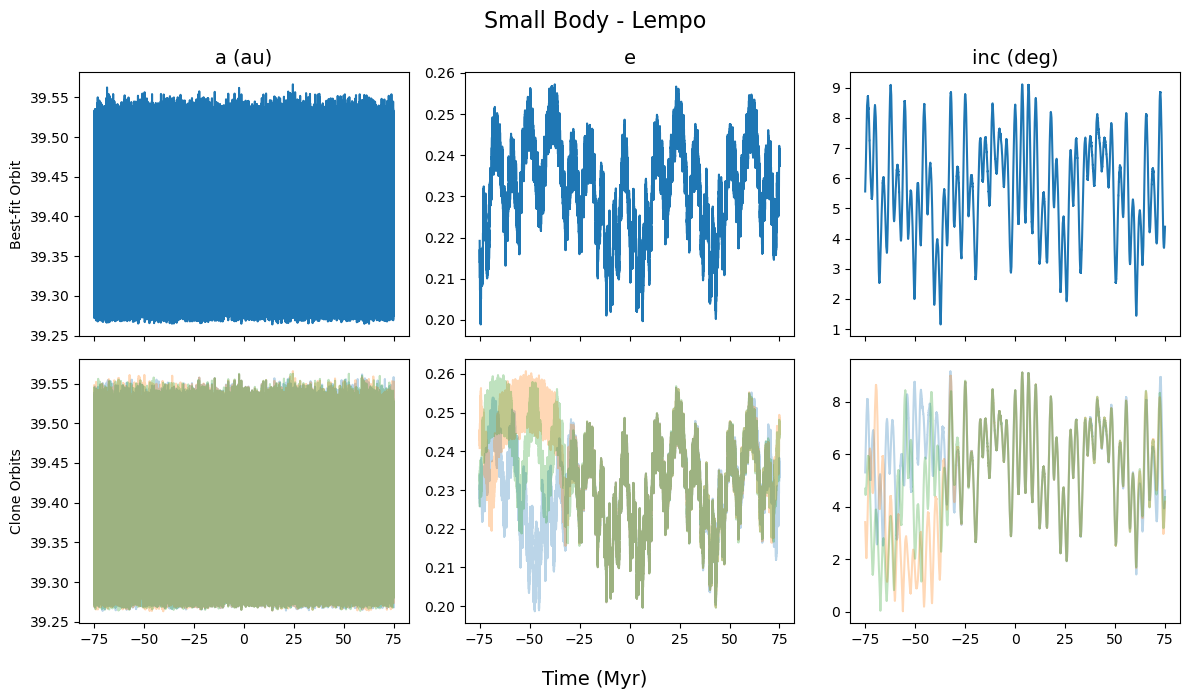

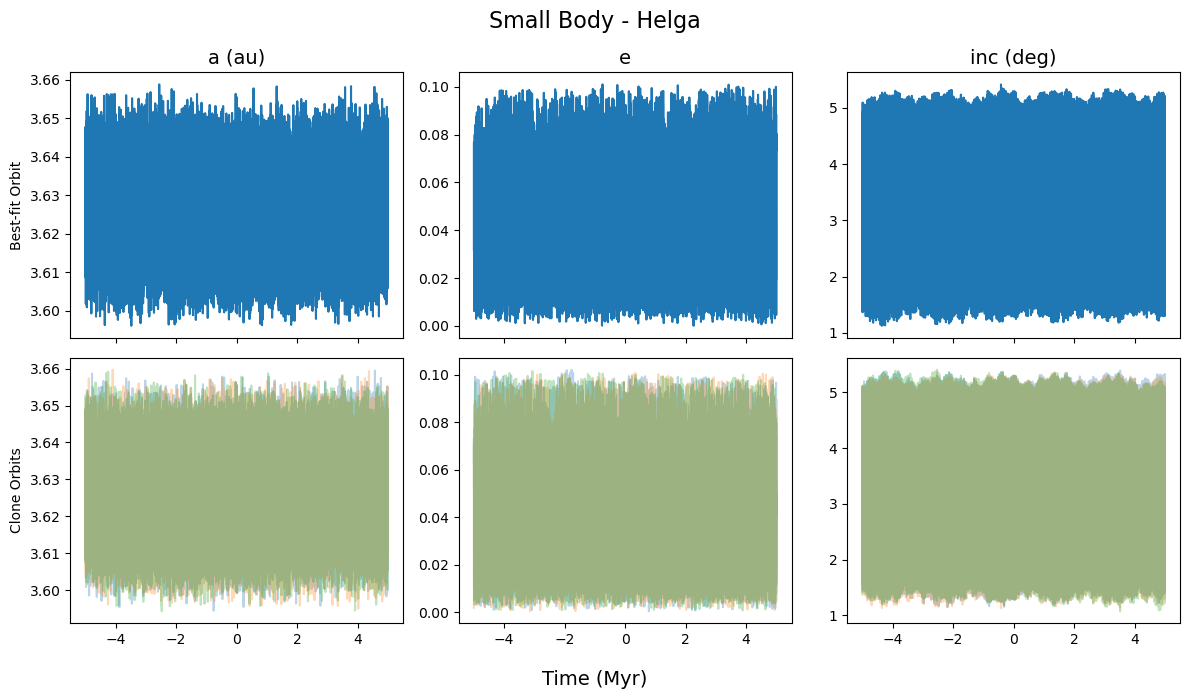

In [9]:
tno_result.stability_indicators.plot_clones()
ast_result.stability_indicators.plot_clones()

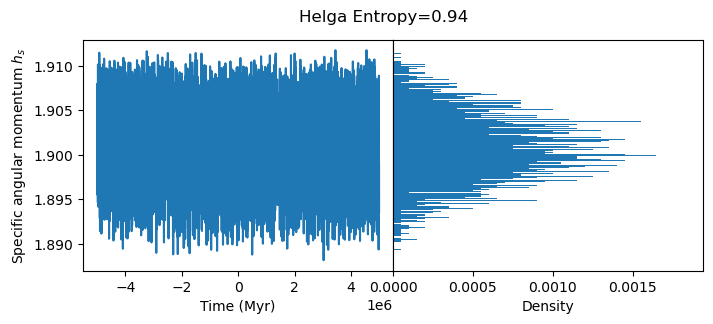

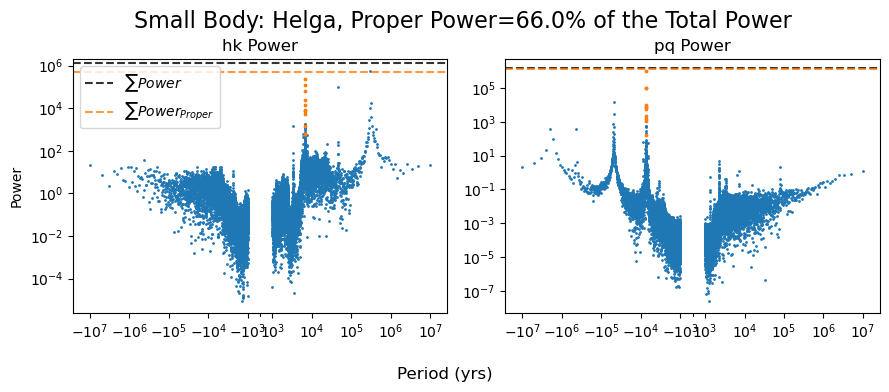

In [10]:
ast_result.stability_indicators.plot_entropy()
ast_result.stability_indicators.plot_power()